In [3]:
import medmnist
from medmnist import ChestMNIST
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Chargement train / val / test
train_dataset = ChestMNIST(split='train', download=True, size=64)
val_dataset   = ChestMNIST(split='val',   download=True, size=64)
test_dataset  = ChestMNIST(split='test',  download=True, size=64)

print(f"Train : {len(train_dataset)}")
print(f"Val   : {len(val_dataset)}")
print(f"Test  : {len(test_dataset)}")

100%|██████████| 402M/402M [00:59<00:00, 6.69MB/s] 


Train : 78468
Val   : 11219
Test  : 22433


In [5]:
# Noms des 14 pathologies
label_names = list(train_dataset.info['label'].values())
print("Pathologies :", label_names)

Pathologies : ['atelectasis', 'cardiomegaly', 'effusion', 'infiltration', 'mass', 'nodule', 'pneumonia', 'pneumothorax', 'consolidation', 'edema', 'emphysema', 'fibrosis', 'pleural', 'hernia']


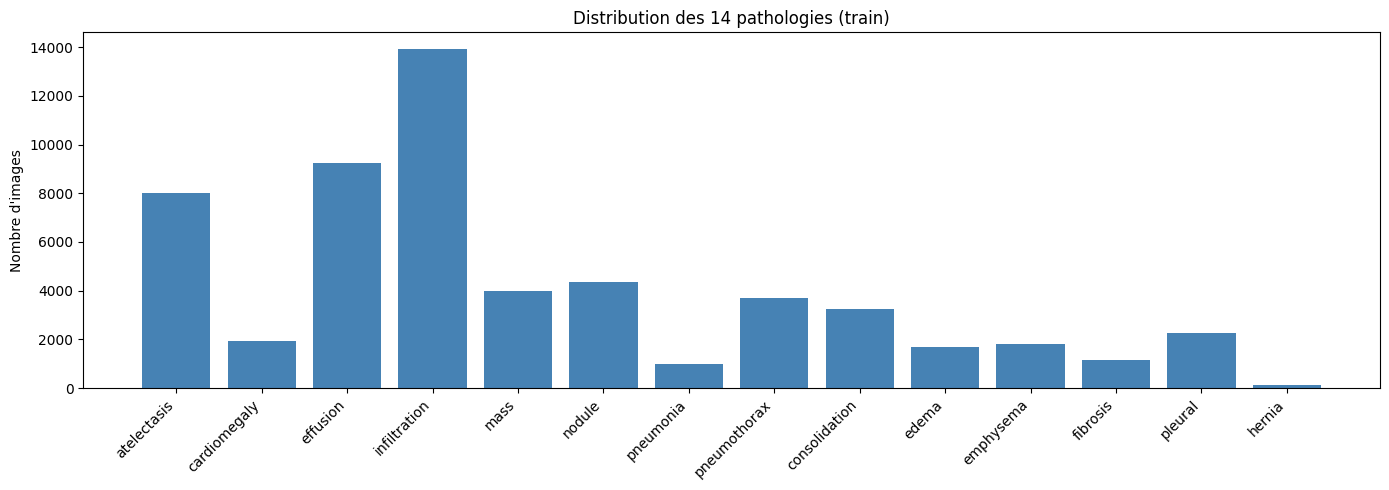

In [6]:
# Récupérer tous les labels du train
all_labels = np.array([label for _, label in train_dataset])

# Compter par pathologie
class_counts = all_labels.sum(axis=0)

plt.figure(figsize=(14, 5))
plt.bar(label_names, class_counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Distribution des 14 pathologies (train)")
plt.ylabel("Nombre d'images")
plt.tight_layout()
plt.show()

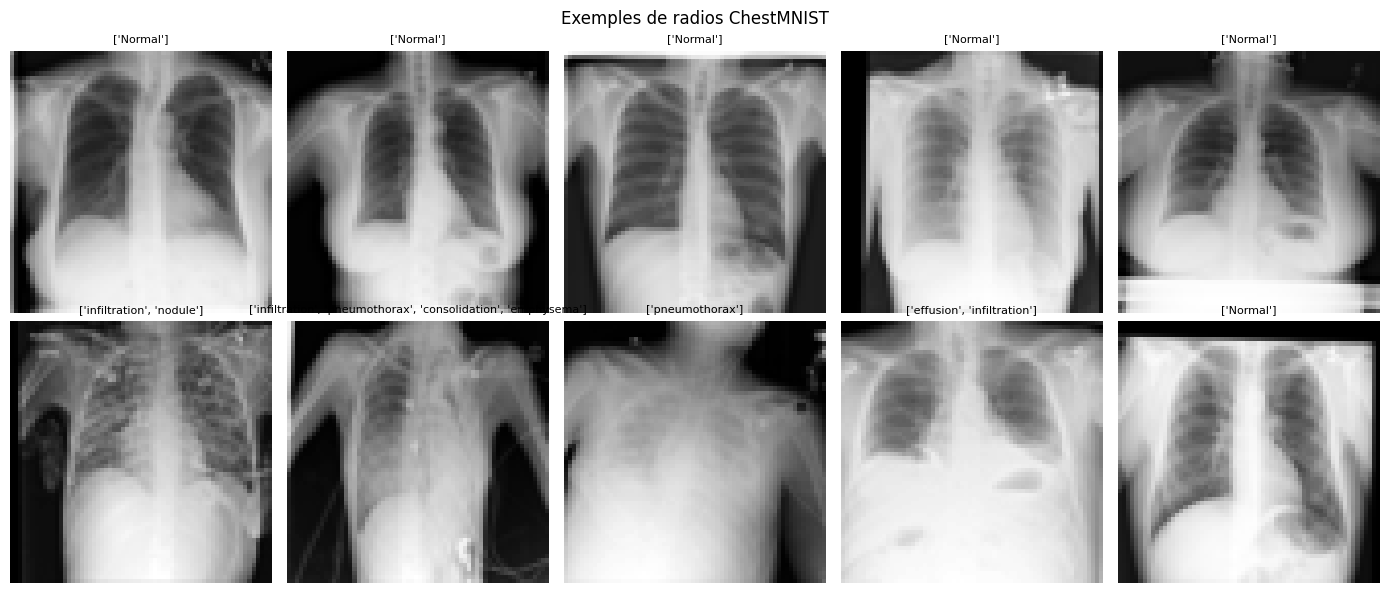

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]
    pathologies = [label_names[j] for j, v in enumerate(label) if v == 1]
    ax.imshow(np.array(img).squeeze(), cmap='gray')
    ax.set_title(pathologies if pathologies else ["Normal"], fontsize=8)
    ax.axis('off')
plt.suptitle("Exemples de radios ChestMNIST")
plt.tight_layout()
plt.show()

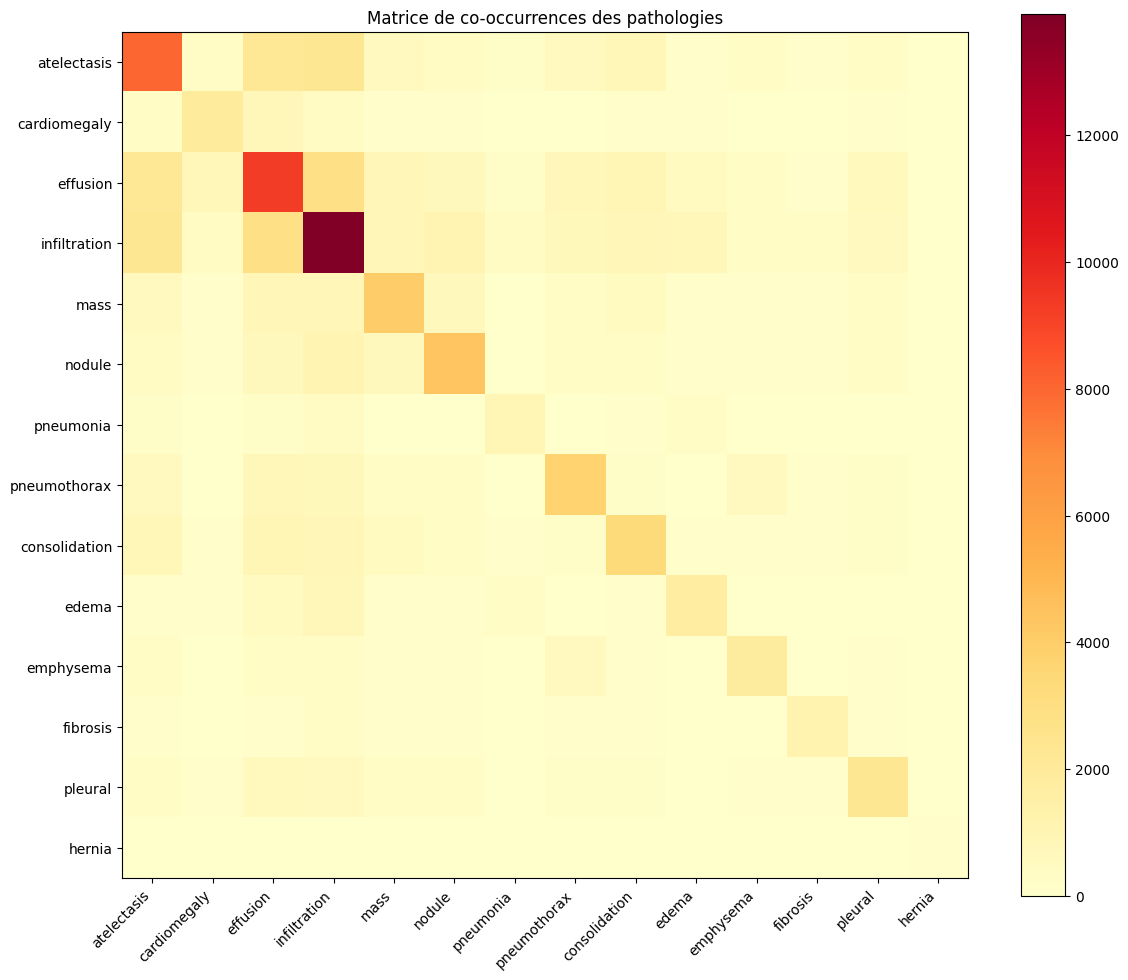

In [10]:
# Matrice de co-occurrences
co_matrix = all_labels.T @ all_labels

plt.figure(figsize=(12, 10))
plt.imshow(co_matrix, cmap='YlOrRd')
plt.colorbar()
plt.xticks(range(14), label_names, rotation=45, ha='right')
plt.yticks(range(14), label_names)
plt.title("Matrice de co-occurrences des pathologies")
plt.tight_layout()
plt.show()